# Chicago Food Inspections: Baseline Modeling

**Dataset:** City of Chicago Food Inspections (July 2018 – March 2026)  

## Objective

This notebook builds and evaluates classification models to predict whether a food inspection will result in a **failure** before the inspection occurs. A reliable model would allow the City of Chicago to prioritize inspection resources toward higher-risk facilities — maximizing the number of genuine failures caught per inspector-hour.

The modeling target is binary: `Fail = 1` (inspection resulted in failure), `Fail = 0` (Pass or Pass w/ Conditions).

Because the dataset is imbalanced (~22.8% fail rate), **recall on the fail class is the primary evaluation metric** — a model that never predicts failure would be 77% accurate while being completely useless. All models use `class_weight='balanced'` to address this.

Three baseline models are tested: Logistic Regression, Decision Tree, and Random Forest. Results are compared and the strongest candidate is identified for future iteration.

---

### **Setup**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Advanced BA/Datasets')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
food = pd.read_csv('food.csv')

### **Modeling Target - Filtered**

In [ ]:
model_df = food[food['Results'].isin(['Pass', 'Pass w/ Conditions', 'Fail'])].copy()
model_df['Inspection Date'] = pd.to_datetime(model_df['Inspection Date'])
model_df['Fail'] = (model_df['Results'] == 'Fail').astype(int)

Records with ambiguous outcomes — `Out of Business`, `No Entry`, `Not Ready`, `Business Not Located` — are excluded from the modeling dataset. These outcomes do not reflect an actual inspection result and would introduce noise into the target variable.

`Pass w/ Conditions` is retained and treated as a non-failure. While these facilities had minor violations, they were not failed — collapsing them with `Pass` keeps the target binary and aligned with the city's own pass/fail designation.

### **Feature Engineering**

#### Temporal

In [ ]:
model_df['Inspection Year'] = model_df['Inspection Date'].dt.year
model_df['Inspection Month'] = model_df['Inspection Date'].dt.month

#### Reducing `Facility Group` dimensionality

In [ ]:
def group_facility(x):
    x = str(x)
    if 'Restaurant' in x:
        return 'Restaurant'
    elif 'Grocery' in x or 'Bakery' in x or 'Food' in x:
        return 'Food Retail'
    elif 'Daycare' in x or 'Children' in x:
        return 'Childcare'
    elif 'School' in x:
        return 'School'
    else:
        return 'Other'

model_df['Facility_Group'] = model_df['Facility Type'].apply(group_facility)

As the raw `Facility Type` field contains over 100+ distinct categories (most with just a few records), encoding would create excessive dimensionality. This function attempts to consolidate them into five, more meaningful groups: `Restaurant`, `Food Retail`, `Childcare`, `School`, and `Other`.

#### Historical Inspection Features

In [ ]:
# remove missing/zero license numbers
model_df = model_df.dropna(subset=['License #']).copy()
model_df = model_df[model_df['License #'] != 0].copy()

# sort so prior-history features are chronological within each license
model_df = model_df.sort_values(['License #', 'Inspection Date']).copy()

# number of prior inspections before current one
model_df['prior_inspections'] = model_df.groupby('License #').cumcount()

# prior failures before current inspection
model_df['prior_failures'] = (
    model_df.groupby('License #')['Fail']
    .transform(lambda x: x.shift().fillna(0).cumsum())
)

# prior fail rate
model_df['prior_fail_rate'] = model_df['prior_failures'] / model_df['prior_inspections']
model_df['prior_fail_rate'] = model_df['prior_fail_rate'].replace([np.inf, -np.inf], 0)
model_df['prior_fail_rate'] = model_df['prior_fail_rate'].fillna(0)

# days since previous inspection
model_df['days_since_last_inspection'] = (
    model_df.groupby('License #')['Inspection Date']
    .diff()
    .dt.days
    .fillna(0)
)

# previous inspection result
model_df['prev_result'] = model_df.groupby('License #')['Fail'].shift(1)

# binary indicator: did the last inspection fail?
model_df['failed_last_inspection'] = model_df['prev_result'].fillna(0).astype(int)

##### Features Added

`prior_inspections`, `prior_failures`, `prior_fail_rate`, `days_since_last_inspection`, `failed_last_inspection`

##### **Design Note**: Preventing Data Leakage

To prevent data leakage, all historical features are calculated using only *prior* inspections. This was achieved by sorting records chronologically by license number before any calculations/

### **Feature Selection**

In [ ]:
X = model_df[[
    'Facility_Group',
    'Zip',
    'Inspection Type',
    'Inspection Year',
    'Inspection Month',
    'prior_inspections',
    'prior_failures',
    'prior_fail_rate',
    'days_since_last_inspection',
    'failed_last_inspection'
]]


y = model_df['Fail']



### **Train/Test Split**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = .3,
                                                    random_state = 42)


### **Preprocessing**

In [ ]:
X_train = pd.get_dummies(X_train, columns=['Facility_Group','Zip', 'Inspection Type'])
X_test = pd.get_dummies(X_test, columns=['Facility_Group','Zip', 'Inspection Type'])
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


Categorical features such as `Facility_Group`, `Zip`, and `Inspection Type` were one-hot encoded.

### **Logistic Regression Baseline**

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2000, solver='liblinear', class_weight = 'balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
lrcm = confusion_matrix(y_test, y_pred)
lrcmdf = pd.DataFrame(lrcm, index=['Actual Fail', 'Actual Pass'], columns=['Predicted Fail', 'Predicted Pass'])
lrcmdf

,Predicted Fail,Predicted Pass
Actual Fail,14445,11378
Actual Pass,2493,5302


In [ ]:
lrcr = classification_report(y_test, y_pred, output_dict=True)
lrcrdf = round(pd.DataFrame(lrcr).T, 2)
lrcrdf

,precision,recall,f1-score,support
0,0.85,0.56,0.68,25823.00
1,0.32,0.68,0.43,7795.00
accuracy,0.59,0.59,0.59,0.59
macro avg,0.59,0.62,0.55,33618.00
weighted avg,0.73,0.59,0.62,33618.00


The logistic regression model served as a balanced and interpretable baseline. It achieved 68% recall on failed inspections, meaning it identified a meaningful share of true failures, but precision for the fail class was only 32%, indicating a large number of false positives. Overall, this model provided a solid starting point and a useful benchmark for comparison with more flexible models.

### **Decision Tree Baseline**

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
model2 = DecisionTreeClassifier(max_depth = 4, random_state = 42, class_weight = 'balanced')
model2.fit(X_train, y_train)

plt.figure(figsize=(15,10))
plot_tree(model2,
          feature_names=X_train.columns,
          class_names=['Pass','Fail'],
          filled=True)
plt.show()



In [ ]:
y_predtree = model2.predict(X_test)
dtcm = confusion_matrix(y_test, y_predtree)
dtcmdf = pd.DataFrame(dtcm, index=['Actual Fail', 'Actual Pass'], columns=['Predicted Fail', 'Predicted Pass'])
dtcmdf

,Predicted Fail,Predicted Pass
Actual Fail,6594,19229
Actual Pass,789,7006


In [ ]:
dtcr = classification_report(y_test, y_predtree, output_dict=True)
dtcrdf = round(pd.DataFrame(dtcr).T, 2)
dtcrdf

,precision,recall,f1-score,support
0,0.89,0.26,0.40,25823.0
1,0.27,0.90,0.41,7795.0
accuracy,0.40,0.40,0.40,0.4
macro avg,0.58,0.58,0.40,33618.0
weighted avg,0.75,0.40,0.40,33618.0


The decision tree achieved the highest recall on failed inspections at 90%, meaning it caught most true failures. However, this came at the cost of a very large number of false positives, which lowered precision for the fail class to 27% and reduced overall accuracy to 40%. Compared with logistic regression, the tree was much more aggressive in predicting failure but less balanced overall.

### **Random Forest Baseline**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [ ]:
cmrf = confusion_matrix(y_test, y_pred_rf)
cmrfdf = pd.DataFrame(cmrf, index=['Actual Fail', 'Actual Pass'], columns=['Predicted Fail', 'Predicted Pass'])
cmrfdf



,Predicted Fail,Predicted Pass
Actual Fail,13003,12820
Actual Pass,1935,5860


In [ ]:
crrf = classification_report(y_test, y_pred_rf, output_dict=True)
crrfdf = round(pd.DataFrame(crrf).T, 2)
crrfdf

,precision,recall,f1-score,support
0,0.87,0.50,0.64,25823.00
1,0.31,0.75,0.44,7795.00
accuracy,0.56,0.56,0.56,0.56
macro avg,0.59,0.63,0.54,33618.00
weighted avg,0.74,0.56,0.59,33618.00


In [ ]:
rf_features = round(pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}), 2)

rf_features = rf_features.sort_values('Importance', ascending=False)
rf_features.head(10)


,Feature,Importance
5,days_since_last_inspection,0.13
6,failed_last_inspection,0.12
109,Inspection Type_Canvass Re-Inspection,0.10
110,Inspection Type_Complaint,0.09
4,prior_fail_rate,0.09
2,prior_inspections,0.05
1,Inspection Month,0.04
3,prior_failures,0.04
0,Inspection Year,0.04
114,Inspection Type_License Re-Inspection,0.04


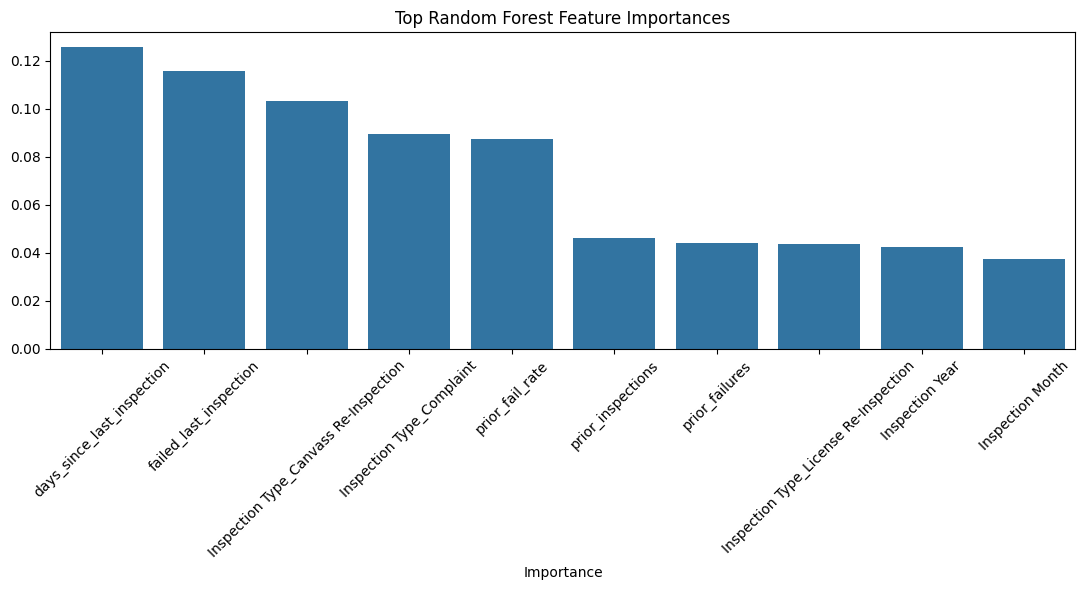

In [ ]:
plt.figure(figsize=(11,6))
top_features = rf_features.head(10)
sns.barplot(data = top_features, x = 'Feature', y = 'Importance')
plt.xticks(rotation = 45);
plt.title('Top Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('')
plt.tight_layout()


The top features by importance are dominated by the historical features that were engineered above. `days_since_last_inspection`, `failed_last_inspection` and `prior_fail_rate` ranked the highest. This supports the findings from the EDA that show a facility's inspection history is a strong predictive signal.

Temporal features such as `Inspection Year` and `Inspection Month`, as well as geogrpahic features `Zip` also contribute meaningfully.

The random forest produced the strongest overall performance on the fail class among the baseline models tested. It improved fail recall to 75% while maintaining a better balance than the decision tree, and it achieved the highest fail-class F1-score at 0.44. Overall, this model provided the best tradeoff so far between identifying failed inspections and limiting excessive false positives.

#### **Model Comparisons**

In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Fail Precision': [0.32, 0.27, 0.31],
    'Fail Recall': [0.68, 0.90, 0.75],
    'Fail F1': [0.43, 0.41, 0.44],
    'Accuracy': [0.59, 0.40, 0.56]
})

comparison_df

,Model,Fail Precision,Fail Recall,Fail F1,Accuracy
0,Logistic Regression,0.32,0.68,0.43,0.59
1,Decision Tree,0.27,0.90,0.41,0.40
2,Random Forest,0.31,0.75,0.44,0.56


**Logistic Regression** is the most interpretable and balanced — reasonable recall without excessive false positives.  
**Decision Tree** maximizes recall at 90% but generates so many false positives that it would overwhelm inspectors with unnecessary visits.  
**Random Forest** offers the best tradeoff — strongest F1 on the fail class and more stable performance than the tree.

The random forest is selected as the strongest baseline and carried forward to cross-validation.

The **Logistic Regression** model is the most interpretable and balanced - has a reasonable recall without excessive false positives

The **Decision Tree** model has a very high recall at 90%, but conversely generates many false positives (too many..)

The **Random Forest** model offers the best tradeoff. It has the strongest F1 on the fail class and is more stable than the decision tree model. This warrants a cross validation on the RF model.

### **Random Forest - Cross Validation**

In [ ]:
from sklearn.model_selection import cross_validate
scores = cross_validate(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1']
)

print(scores)
pd.DataFrame(scores).mean()

{'fit_time': array([6.71728373, 4.87262893, 8.00586772, 5.14539838, 6.24273348]), 'score_time': array([0.19682384, 0.19418788, 0.1818459 , 0.18497753, 0.41781545]), 'test_accuracy': array([0.55150433, 0.57508924, 0.56533656, 0.57336818, 0.54286989]), 'test_precision': array([0.3       , 0.31055068, 0.30579693, 0.30971734, 0.29616685]), 'test_recall': array([0.73397075, 0.71681665, 0.72244094, 0.71794151, 0.73895921]), 'test_f1': array([0.42591384, 0.433356  , 0.42970645, 0.43274854, 0.42285714])}


,0
fit_time,6.196782
score_time,0.235130
test_accuracy,0.561634
test_precision,0.304446
test_recall,0.726026
test_f1,0.428916


Cross-validation results are pretty consistent with the test performance, confirming the random forest model's results are not an artifact of a particular test/train split. Recall remains relatively strong across folds while precision stays modest.

**Random Forest Interpretations** - The RF's 75% recall on the fail class indicates that out of 100 facilities that will *actually* fail their inspection, the model will flag around 75 of them for priority review.

Without any modeling, randomly selecting facilities for priority inspection would surface only around 23 failing facilities per 100 (the base fail rate of ~22.8%).

However, the precision remains low on the fail class (~31%), indicating that around 2 out of every 3 flagged facilities would *actually* pass. **This indicates that the model can be useful for prioritization rather than definitive predictions**.